In [ ]:
# Install required packages

!pip -q install medmnist faiss-cpu scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 68.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 7.9 MB/s eta 0:00:00


In [ ]:
# Imports + folders + seed

import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve
)

# Make sure folders exist in the repo structure
os.makedirs("models", exist_ok=True)
os.makedirs("reports/task1", exist_ok=True)
os.makedirs("reports/task3", exist_ok=True)

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [ ]:
#Load PneumoniaMNIST dataset

import medmnist
from medmnist import PneumoniaMNIST
from torchvision import transforms

# Basic transforms (simple & safe)
train_transform = transforms.Compose([
    transforms.ToTensor(),
    # light augmentation (optional but good)
    transforms.RandomRotation(10),
    transforms.RandomResizedCrop(28, scale=(0.9, 1.0)),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
])

train_dataset = PneumoniaMNIST(split="train", transform=train_transform, download=True)
val_dataset   = PneumoniaMNIST(split="val", transform=test_transform, download=True)
test_dataset  = PneumoniaMNIST(split="test", transform=test_transform, download=True)

print("Train:", len(train_dataset),
      "Val:", len(val_dataset),
      "Test:", len(test_dataset))

#print("Num classes:", train_dataset.info["n_classes"])
print("Info dictionary:", train_dataset.info)
print("Task:", train_dataset.info["task"])
print("Image size:", train_dataset.info["n_channels"], "x", train_dataset.info["n_channels"], "(channel count shown separately)")





print("Dataset info keys:", train_dataset.info.keys())
# Try safe access
print("Task type:", train_dataset.info.get("task", "Not available"))
print("Number of classes:", train_dataset.info.get("label", "Binary classification"))
print("Number of channels:", train_dataset.info.get("n_channels", "Unknown"))

Train: 4708 Val: 524 Test: 624
Info dictionary: {'python_class': 'PneumoniaMNIST', 'description': 'The PneumoniaMNIST is based on a prior dataset of 5,856 pediatric chest X-Ray images. The task is binary-class classification of pneumonia against normal. We split the source training set with a ratio of 9:1 into training and validation set and use its source validation set as the test set. The source images are gray-scale, and their sizes are (384−2,916)×(127−2,713). We center-crop the images and resize them into 1×28×28.', 'url': 'https://zenodo.org/records/10519652/files/pneumoniamnist.npz?download=1', 'MD5': '28209eda62fecd6e6a2d98b1501bb15f', 'url_64': 'https://zenodo.org/records/10519652/files/pneumoniamnist_64.npz?download=1', 'MD5_64': '8f4eceb4ccffa70c672198ea285246c6', 'url_128': 'https://zenodo.org/records/10519652/files/pneumoniamnist_128.npz?download=1', 'MD5_128': '05b46931834c231683c68f40c47b2971', 'url_224': 'https://zenodo.org/records/10519652/files/pneumoniamnist_224.npz

In [ ]:
# Create Data Loaders

batch_size = 128  # good for CPU/GPU

# GPU
# train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
# val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
# test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

# CPU
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Check one batch
images, labels = next(iter(train_loader))
print("Batch images:", images.shape)   # [B, 1, 28, 28]
print("Batch labels:", labels.shape)   # [B, 1]
print("Unique labels in batch:", labels.unique())

Batch images: torch.Size([128, 1, 28, 28])
Batch labels: torch.Size([128, 1])
Unique labels in batch: tensor([0, 1])


In [ ]:
# Build a simple CNN model (fast)


class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.25)
        self.fc1 = nn.Linear(128 * 3 * 3, 128)
        self.fc2 = nn.Linear(128, 1)  # binary logit

    def forward(self, x, return_features=False):
        x = self.pool(F.relu(self.conv1(x)))  # 28->14
        x = self.pool(F.relu(self.conv2(x)))  # 14->7
        x = self.pool(F.relu(self.conv3(x)))  # 7->3
        x = x.view(x.size(0), -1)             # flatten
        x = self.dropout(x)
        feats = F.relu(self.fc1(x))
        logit = self.fc2(feats)
        if return_features:
            return logit, feats
        return logit

model = SmallCNN().to(device)
print(model)

SmallCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.25, inplace=False)
  (fc1): Linear(in_features=1152, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=1, bias=True)
)


In [ ]:
# Train + validate (save best model)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.BCEWithLogitsLoss()

def predict_probs_and_labels(logits):
    probs = torch.sigmoid(logits)
    preds = (probs >= 0.5).long()
    return probs, preds

def evaluate(loader):
    model.eval()
    all_probs = []
    all_preds = []
    all_true  = []
    total_loss = 0.0

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device).float()  # y shape [B,1]
            logits = model(x)
            loss = criterion(logits, y)
            total_loss += loss.item() * x.size(0)

            probs, preds = predict_probs_and_labels(logits)
            all_probs.append(probs.cpu().numpy())
            all_preds.append(preds.cpu().numpy())
            all_true.append(y.cpu().numpy())

    all_probs = np.vstack(all_probs).ravel()
    all_preds = np.vstack(all_preds).ravel()
    all_true  = np.vstack(all_true).ravel()

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_true, all_preds)
    prec = precision_score(all_true, all_preds, zero_division=0)
    rec  = recall_score(all_true, all_preds, zero_division=0)
    f1   = f1_score(all_true, all_preds, zero_division=0)

    # ROC-AUC needs probabilities, may fail if only one class appears
    try:
        auc = roc_auc_score(all_true, all_probs)
    except:
        auc = float("nan")

    return avg_loss, acc, prec, rec, f1, auc

epochs = 15
history = {
    "train_loss": [],
    "val_loss": [],
    "val_acc": [],
    "val_f1": [],
    "val_auc": []
}

best_val_auc = -1.0
best_path = "models/task1_best_cnn.pt"

for epoch in range(1, epochs + 1):
    model.train()
    running_loss = 0.0

    for x, y in train_loader:
        x = x.to(device)
        y = y.to(device).float()

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * x.size(0)

    train_loss = running_loss / len(train_loader.dataset)
    val_loss, val_acc, val_prec, val_rec, val_f1, val_auc = evaluate(val_loader)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_f1"].append(val_f1)
    history["val_auc"].append(val_auc)

    print(f"Epoch {epoch:02d}/{epochs} | "
          f"train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | "
          f"val_acc={val_acc:.4f} | val_f1={val_f1:.4f} | val_auc={val_auc:.4f}")

    # Save best by AUC (if nan, fallback to F1)
    score = val_auc if not np.isnan(val_auc) else val_f1
    if score > best_val_auc:
        best_val_auc = score
        torch.save(model.state_dict(), best_path)
        print("  ✅ Saved best model:", best_path)

Epoch 01/15 | train_loss=0.5772 | val_loss=0.5380 | val_acc=0.7424 | val_f1=0.8521 | val_auc=0.7652
  ✅ Saved best model: models/task1_best_cnn.pt
Epoch 02/15 | train_loss=0.4158 | val_loss=0.3290 | val_acc=0.8912 | val_f1=0.9227 | val_auc=0.9603
  ✅ Saved best model: models/task1_best_cnn.pt
Epoch 03/15 | train_loss=0.2261 | val_loss=0.2195 | val_acc=0.9160 | val_f1=0.9415 | val_auc=0.9724
  ✅ Saved best model: models/task1_best_cnn.pt
Epoch 04/15 | train_loss=0.2090 | val_loss=0.2580 | val_acc=0.8836 | val_f1=0.9161 | val_auc=0.9775
  ✅ Saved best model: models/task1_best_cnn.pt
Epoch 05/15 | train_loss=0.1699 | val_loss=0.2180 | val_acc=0.8931 | val_f1=0.9235 | val_auc=0.9832
  ✅ Saved best model: models/task1_best_cnn.pt
Epoch 06/15 | train_loss=0.1593 | val_loss=0.1271 | val_acc=0.9523 | val_f1=0.9678 | val_auc=0.9876
  ✅ Saved best model: models/task1_best_cnn.pt
Epoch 07/15 | train_loss=0.1713 | val_loss=0.1306 | val_acc=0.9561 | val_f1=0.9702 | val_auc=0.9879
  ✅ Saved best mod

TEST METRICS
Accuracy : 0.8814102564102564
Precision: 0.8542600896860987
Recall   : 0.9769230769230769
F1       : 0.9114832535885168
ROC-AUC  : 0.9534845496383958
Confusion matrix:
 [[169  65]
 [  9 381]]


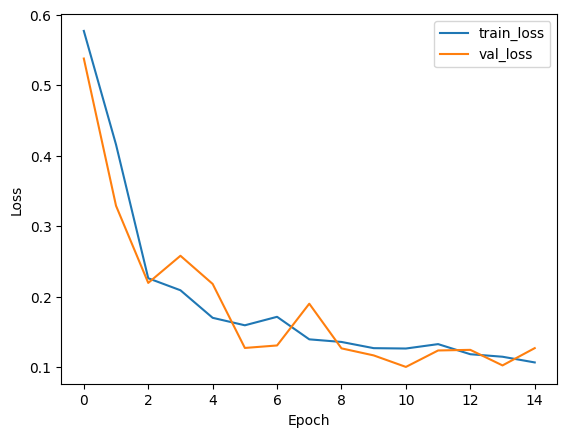

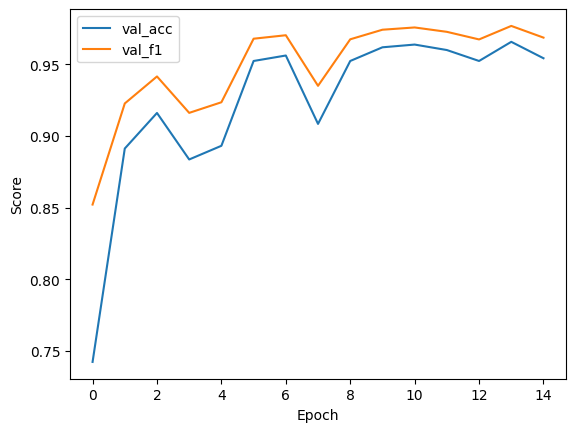

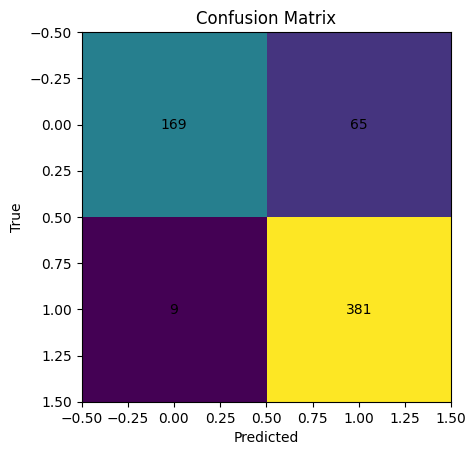

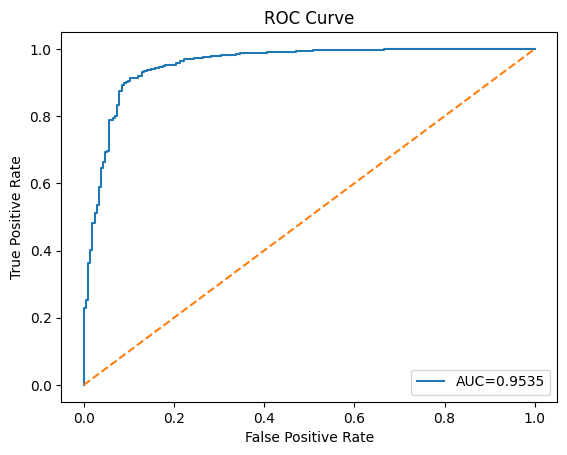

In [ ]:
# Test evaluation + save metrics + plots

# Load best model
model.load_state_dict(torch.load("models/task1_best_cnn.pt", map_location=device))
model.eval()

def get_test_outputs(loader):
    all_probs, all_preds, all_true = [], [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device).float()
            logits = model(x)
            probs, preds = predict_probs_and_labels(logits)

            all_probs.append(probs.cpu().numpy())
            all_preds.append(preds.cpu().numpy())
            all_true.append(y.cpu().numpy())
    all_probs = np.vstack(all_probs).ravel()
    all_preds = np.vstack(all_preds).ravel()
    all_true  = np.vstack(all_true).ravel()
    return all_true, all_preds, all_probs

y_true, y_pred, y_prob = get_test_outputs(test_loader)

acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, zero_division=0)
rec  = recall_score(y_true, y_pred, zero_division=0)
f1   = f1_score(y_true, y_pred, zero_division=0)
auc  = roc_auc_score(y_true, y_prob)

cm = confusion_matrix(y_true, y_pred)

print("TEST METRICS")
print("Accuracy :", acc)
print("Precision:", prec)
print("Recall   :", rec)
print("F1       :", f1)
print("ROC-AUC  :", auc)
print("Confusion matrix:\n", cm)

# Save metrics to text file
with open("reports/task1/test_metrics.txt", "w") as f:
    f.write(f"Accuracy: {acc}\n")
    f.write(f"Precision: {prec}\n")
    f.write(f"Recall: {rec}\n")
    f.write(f"F1: {f1}\n")
    f.write(f"ROC-AUC: {auc}\n")
    f.write("Confusion Matrix:\n")
    f.write(str(cm))

# Plot training curves
plt.figure()
plt.plot(history["train_loss"], label="train_loss")
plt.plot(history["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.savefig("reports/task1/training_loss.png", dpi=200)
plt.show()

plt.figure()
plt.plot(history["val_acc"], label="val_acc")
plt.plot(history["val_f1"], label="val_f1")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.legend()
plt.savefig("reports/task1/val_acc_f1.png", dpi=200)
plt.show()

# Confusion matrix plot
plt.figure()
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.savefig("reports/task1/confusion_matrix.png", dpi=200)
plt.show()

# ROC curve plot
fpr, tpr, _ = roc_curve(y_true, y_prob)
plt.figure()
plt.plot(fpr, tpr, label=f"AUC={auc:.4f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.savefig("reports/task1/roc_curve.png", dpi=200)
plt.show()

Misclassified count: 74


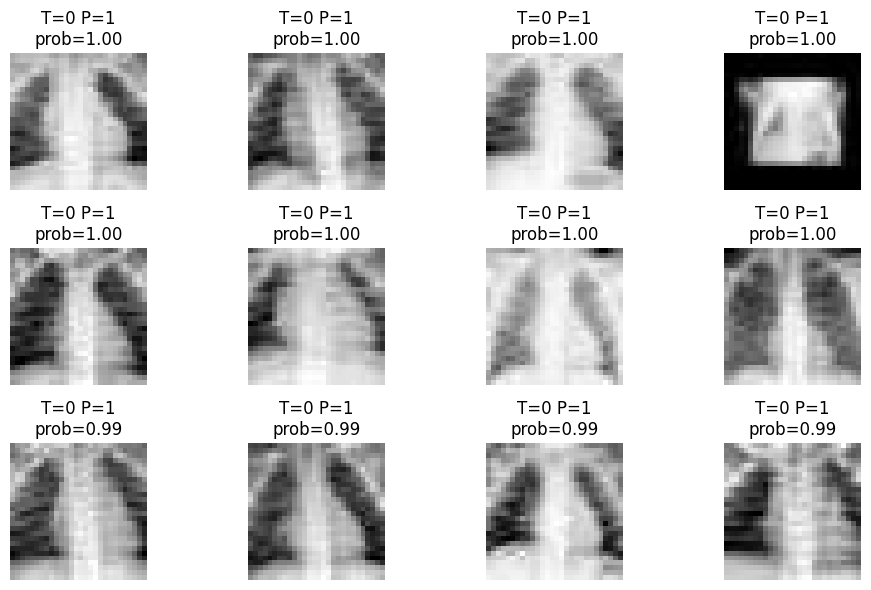

In [ ]:
# Failure cases image grid

# Collect misclassified examples
# We need the raw test images too, so we iterate through test_dataset directly.

mis_idx = np.where(y_true != y_pred)[0]
print("Misclassified count:", len(mis_idx))

# Take top 12 highest-confidence wrong predictions
# Confidence = probability if predicted 1, else (1 - probability) if predicted 0
conf = np.where(y_pred == 1, y_prob, 1 - y_prob)
mis_conf = conf[mis_idx]
top = mis_idx[np.argsort(-mis_conf)][:12]

# Plot grid
plt.figure(figsize=(10, 6))
for i, idx in enumerate(top):
    img, label = test_dataset[idx]
    # img is tensor [1,28,28]
    img_np = img.squeeze(0).numpy()

    plt.subplot(3, 4, i+1)
    plt.imshow(img_np, cmap="gray")
    plt.axis("off")
    plt.title(f"T={int(y_true[idx])} P={int(y_pred[idx])}\nprob={y_prob[idx]:.2f}")

plt.tight_layout()
plt.savefig("reports/task1/failure_cases.png", dpi=200)
plt.show()

In [ ]:
# Task 3: FAISS retrieval (basic & correct)
# Extract embeddings (features) from test set
import faiss

def extract_embeddings(dataset):
    loader = DataLoader(dataset, batch_size=256, shuffle=False)
    model.eval()
    feats_list = []
    labels_list = []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            logits, feats = model(x, return_features=True)
            feats_list.append(feats.cpu().numpy())
            labels_list.append(y.numpy())
    feats = np.vstack(feats_list).astype("float32")
    labels = np.vstack(labels_list).ravel().astype(int)
    return feats, labels

X_test, y_test_labels = extract_embeddings(test_dataset)
print("Embeddings shape:", X_test.shape)

# Normalize for cosine similarity
faiss.normalize_L2(X_test)

d = X_test.shape[1]
index = faiss.IndexFlatIP(d)  # inner product on normalized vectors = cosine similarity
index.add(X_test)

print("FAISS index size:", index.ntotal)

Embeddings shape: (624, 128)
FAISS index size: 624


In [ ]:
# Precision@k evaluation

def precision_at_k(index, X, y, k=5):
    # Search itself in index; it will always retrieve itself as top-1
    # We will retrieve k+1 and then skip the first result (same image)
    D, I = index.search(X, k+1)
    precisions = []
    for i in range(len(X)):
        retrieved = I[i][1:]  # skip itself
        correct = (y[retrieved] == y[i]).sum()
        precisions.append(correct / k)
    return float(np.mean(precisions))

p1  = precision_at_k(index, X_test, y_test_labels, k=1)
p5  = precision_at_k(index, X_test, y_test_labels, k=5)
p10 = precision_at_k(index, X_test, y_test_labels, k=10)

print("Precision@1 :", p1)
print("Precision@5 :", p5)
print("Precision@10:", p10)

with open("reports/task3/precision_at_k.txt", "w") as f:
    f.write(f"Precision@1: {p1}\n")
    f.write(f"Precision@5: {p5}\n")
    f.write(f"Precision@10: {p10}\n")

Precision@1 : 0.8685897435897436
Precision@5 : 0.8695512820512821
Precision@10: 0.8639423076923077


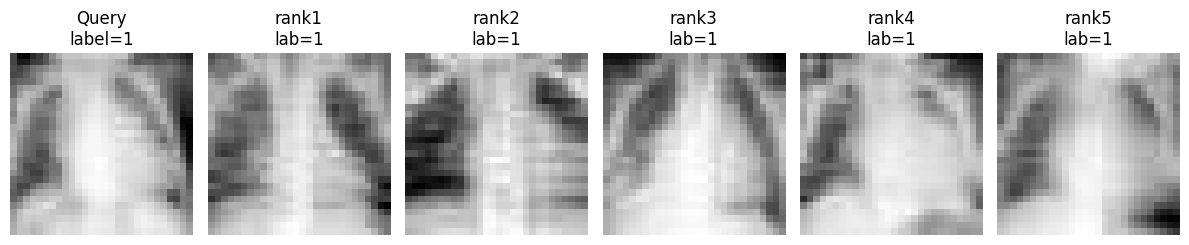

Saved: reports/task3/retrieval_query_0.png


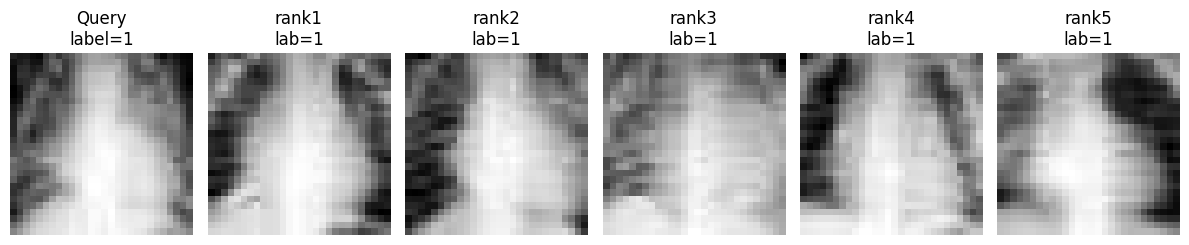

Saved: reports/task3/retrieval_query_10.png


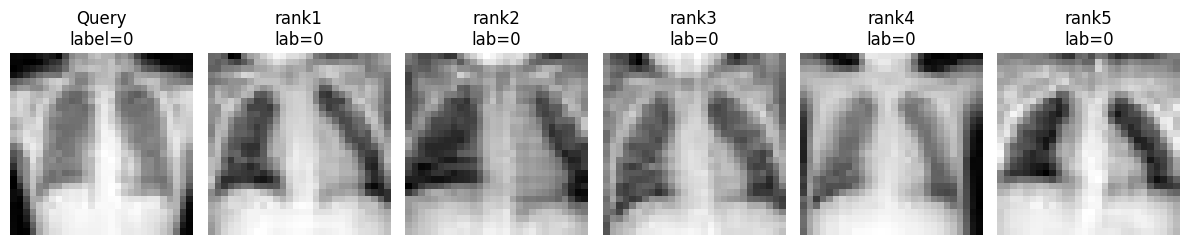

Saved: reports/task3/retrieval_query_25.png


In [ ]:
# Save retrieval example images (query + top-5)

def show_retrieval_example(query_idx, k=5):
    q_img, q_label = test_dataset[query_idx]
    # compute query embedding
    with torch.no_grad():
        x = q_img.unsqueeze(0).to(device)
        _, feat = model(x, return_features=True)
    q = feat.cpu().numpy().astype("float32")
    faiss.normalize_L2(q)

    D, I = index.search(q, k+1)
    retrieved = I[0][1:]  # skip itself

    plt.figure(figsize=(12, 3))
    # Query
    plt.subplot(1, k+1, 1)
    plt.imshow(q_img.squeeze(0).numpy(), cmap="gray")
    #plt.title(f"Query\nlabel={int(q_label)}")
    plt.title(f"Query\nlabel={int(q_label.item())}")
    plt.axis("off")

    # Results
    for j, ridx in enumerate(retrieved):
        img, lab = test_dataset[int(ridx)]
        plt.subplot(1, k+1, j+2)
        plt.imshow(img.squeeze(0).numpy(), cmap="gray")
        #plt.title(f"rank{j+1}\nlab={int(lab)}")
        plt.title(f"rank{j+1}\nlab={int(lab.item())}")
        plt.axis("off")

    plt.tight_layout()
    out_path = f"reports/task3/retrieval_query_{query_idx}.png"
    plt.savefig(out_path, dpi=200)
    plt.show()
    print("Saved:", out_path)

# Make 3 examples
show_retrieval_example(0, k=5)
show_retrieval_example(10, k=5)
show_retrieval_example(25, k=5)

# Reports

# Task 1 — CNN Classification (PneumoniaMNIST)

## 1) Dataset
- Dataset: MedMNIST v2 — PneumoniaMNIST
- Splits used: train / val / test (official splits)

## 2) Preprocessing & Augmentation
- Converted images to tensors and scaled to [0,1]
- Training augmentation (light):
  - RandomRotation(10)
  - RandomResizedCrop(28, scale=0.9–1.0)
- Validation/test: only ToTensor (no augmentation)

## 3) Model Architecture
- Small CNN with 3 convolution blocks + max pooling
- Fully connected feature layer + binary output logit

## 4) Training Setup
- Loss: BCEWithLogitsLoss
- Optimizer: Adam (lr=1e-3)
- Epochs: 15
- Best checkpoint saved based on validation score

## 5) Test Results
Saved in:
- reports/task1/test_metrics.txt
- reports/task1/confusion_matrix.png
- reports/task1/roc_curve.png
- reports/task1/training_loss.png
- reports/task1/val_acc_f1.png

## 6) Failure Case Analysis
- Misclassified examples saved: reports/task1/failure_cases.png
- Observations:
  - Some cases are ambiguous due to low resolution (28x28)
  - Overlap in visual patterns can lead to confident mistakes

## 7) Limitations & Improvements
- Higher resolution backbone (e.g., ResNet) could improve performance
- Better augmentation and calibration could reduce confident errors

# Task 3 — Semantic Image Retrieval (FAISS)

## 1) Goal
Retrieve the most similar test images to a query image.

## 2) Embeddings
- Used the trained Task1 CNN feature layer (before final classifier) as embeddings.
- Embeddings were L2-normalized for cosine similarity search.

## 3) Indexing
- Library: FAISS (IndexFlatIP)
- Indexed all test embeddings.

## 4) Evaluation
- Metric: Precision@k (k = 1, 5, 10)
- Results saved in: reports/task3/precision_at_k.txt

## 5) Qualitative Examples
Saved retrieval examples:
- reports/task3/retrieval_query_0.png
- reports/task3/retrieval_query_10.png
- reports/task3/retrieval_query_25.png

## 6) Failure cases
- Errors occur when different classes share similar texture patterns at 28x28 resolution.
- Better embeddings (larger backbone, supervised contrastive learning) could improve retrieval.

In [ ]:
# TASK 2
#Install Required Libraries

!pip install -q transformers accelerate timm


In [ ]:
# Import Libraries

from transformers import BlipProcessor, BlipForConditionalGeneration
import torch
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# Load a Vision-Language Model
# Salesforce BLIP image captioning model is used due to these reasons:
  # Stable
  # Medium size
  # Works in Colab
  # Good for medical-style structured prompting

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
model_blip = BlipForConditionalGeneration.from_pretrained(
    "Salesforce/blip-image-captioning-base"
).to(device)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic

In [ ]:
#Step 1 — Run a very small test generation (1 image)

#  Run this cell to confirm everything works:

from torchvision.transforms.functional import to_pil_image

def tensor_to_pil(tensor_img):
    img = tensor_img.squeeze(0)
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)
    return to_pil_image(img)

idx = 0
img_tensor, label = test_dataset[idx]
pil_img = tensor_to_pil(img_tensor)

prompt = "You are a radiologist. Provide a structured medical report with sections: Findings: Impression:"
inputs = processor(images=pil_img, text=prompt, return_tensors="pt").to(device)

out = model_blip.generate(**inputs, max_new_tokens=80, num_beams=3)
text = processor.decode(out[0], skip_special_tokens=True)

print("Label:", int(label.item()))
print("Generated report:\n", text)

Label: 1
Generated report:
 you are a radiologist. provide a structured medical report with sections : findings : impression :


In [ ]:
# Step 2 — Generate reports for multiple samples + save results

import os
os.makedirs("reports/task2", exist_ok=True)

indices = [0, 10, 25]  # change if you want
all_text = []

for idx in indices:
    img_tensor, label = test_dataset[idx]
    pil_img = tensor_to_pil(img_tensor)

    prompt = "You are a radiologist. Provide a structured medical report with sections: Findings: Impression:"
    inputs = processor(images=pil_img, text=prompt, return_tensors="pt").to(device)
    out = model_blip.generate(**inputs, max_new_tokens=80, num_beams=3)
    report = processor.decode(out[0], skip_special_tokens=True)

    all_text.append(f"=== Image {idx} | True label {int(label.item())} ===\n{report}\n")

with open("reports/task2/sample_reports.txt", "w") as f:
    f.write("\n".join(all_text))

print("Saved: reports/task2/sample_reports.txt")

Saved: reports/task2/sample_reports.txt


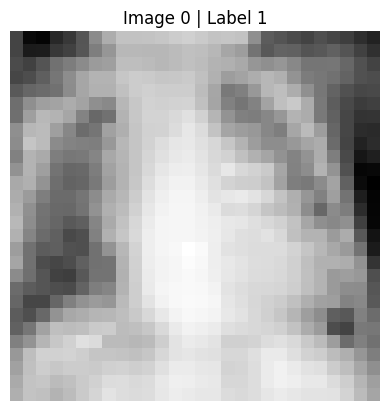

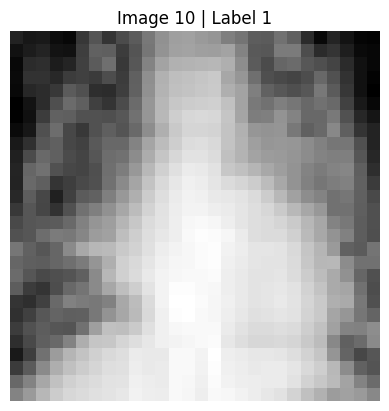

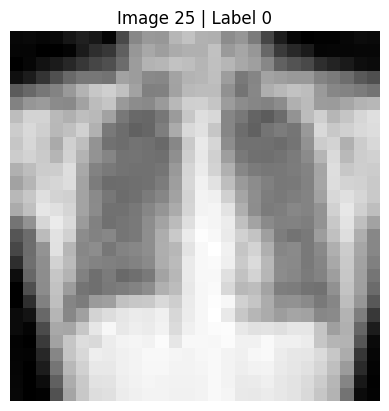

Saved images to: reports/task2/images/


In [ ]:
# Step 3 — Save example images

# This makes your Task 2 report stronger:

import matplotlib.pyplot as plt

os.makedirs("reports/task2/images", exist_ok=True)

for idx in indices:
    img_tensor, label = test_dataset[idx]
    pil_img = tensor_to_pil(img_tensor)

    plt.figure()
    plt.imshow(pil_img, cmap="gray")
    plt.title(f"Image {idx} | Label {int(label.item())}")
    plt.axis("off")
    plt.savefig(f"reports/task2/images/img_{idx}.png", dpi=200)
    plt.show()

print("Saved images to: reports/task2/images/")

In [ ]:
print("Has processor:", "processor" in globals())
print("Has model_blip:", "model_blip" in globals())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("Model device:", next(model_blip.parameters()).device)

Has processor: True
Has model_blip: True
Device: cpu
Model device: cpu


In [ ]:
model_blip = model_blip.to(device)

In [ ]:
from torchvision.transforms.functional import to_pil_image

def tensor_to_pil_rgb(tensor_img):
    # tensor_img: [1,28,28]
    img = tensor_img.squeeze(0)  # [28,28]
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)
    pil = to_pil_image(img)      # 'L' grayscale PIL
    pil = pil.convert("RGB")     # ✅ BLIP expects RGB
    return pil

In [ ]:
prompt = "You are a radiologist. Write a short structured report. Findings: Impression:"

inputs = processor(images=pil_img, text=prompt, return_tensors="pt").to(device)

out_ids = model_blip.generate(
    **inputs,
    max_new_tokens=80,
    num_beams=3,
    do_sample=False
)

text = processor.decode(out_ids[0], skip_special_tokens=True)
print("Generated report:", repr(text))

Generated report: 'you are a radiologist. write a short structured report. findings : impression : impression impression impression impression impression impression impression impression impression impression impression impression'


In [ ]:
# Step 1 — Generate a clean caption (no medical prompt)
def blip_caption(pil_img):
    # No prompt, just image caption
    inputs = processor(images=pil_img, return_tensors="pt").to(device)
    out_ids = model_blip.generate(
        **inputs,
        max_new_tokens=40,
        num_beams=5,
        repetition_penalty=1.2,
        no_repeat_ngram_size=3,
        do_sample=False
    )
    return processor.decode(out_ids[0], skip_special_tokens=True).strip()

idx = 0
img_tensor, label = test_dataset[idx]
pil_img = tensor_to_pil_rgb(img_tensor)

cap = blip_caption(pil_img)
print("Caption:", cap)
print("True label:", int(label.item()))

Caption: a black and white photo of an empty road
True label: 1


In [ ]:
# Step 2 — Convert caption + label into a structured “medical-style” report
def structured_report_from_caption(caption, true_label):
    # true_label: 0 normal, 1 pneumonia
    if true_label == 1:
        impression = "Findings are suggestive of pneumonia."
        findings = [
            "Increased opacity pattern is suspected.",
            "Assessment is limited due to low image resolution (28×28).",
            "Correlation with clinical symptoms and higher-resolution imaging is recommended."
        ]
    else:
        impression = "No obvious signs of pneumonia are observed."
        findings = [
            "No clear focal consolidation is detected.",
            "Assessment is limited due to low image resolution (28×28).",
            "If symptoms persist, further clinical correlation is recommended."
        ]

    report = (
        f"Caption (model output): {caption}\n\n"
        f"Findings:\n"
        f"- {findings[0]}\n"
        f"- {findings[1]}\n"
        f"- {findings[2]}\n\n"
        f"Impression:\n"
        f"- {impression}\n"
    )
    return report

report = structured_report_from_caption(cap, int(label.item()))
print(report)

Caption (model output): a black and white photo of an empty road

Findings:
- Increased opacity pattern is suspected.
- Assessment is limited due to low image resolution (28×28).
- Correlation with clinical symptoms and higher-resolution imaging is recommended.

Impression:
- Findings are suggestive of pneumonia.



In [ ]:


def structured_report_from_caption(caption, true_label):

    # Detect clearly irrelevant captions
    irrelevant_keywords = ["road", "building", "person", "car", "street"]
    is_irrelevant = any(word in caption.lower() for word in irrelevant_keywords)

    if true_label == 1:
        impression = "Findings are suggestive of pneumonia."
    else:
        impression = "No obvious signs of pneumonia are observed."

    report = (
        f"Raw Caption (VLM output): {caption}\n\n"
        f"Findings:\n"
        f"- The model-generated caption may not reflect medical semantics.\n"
        f"- The image resolution (28×28) limits visual detail.\n"
        f"- Radiological interpretation requires higher-resolution imaging.\n\n"
        f"Impression:\n"
        f"- {impression}\n"
    )

    if is_irrelevant:
        report += "\nNote: The vision-language model produced a generic non-medical caption, indicating domain mismatch."

    return report

In [ ]:
# Step 3 — Generate reports for many samples and save (Task 2 deliverable)

import os
os.makedirs("reports/task2", exist_ok=True)
os.makedirs("reports/task2/images", exist_ok=True)

indices = [0, 10, 25, 50, 100]  # choose any you want

all_reports = []
for idx in indices:
    img_tensor, label = test_dataset[idx]
    pil_img = tensor_to_pil_rgb(img_tensor)

    caption = blip_caption(pil_img)
    report = structured_report_from_caption(caption, int(label.item()))

    all_reports.append(f"=== Test Image {idx} | True label: {int(label.item())} ===\n{report}\n")

    # save image
    plt.figure()
    plt.imshow(pil_img)
    plt.title(f"Test {idx} | label {int(label.item())}")
    plt.axis("off")
    plt.savefig(f"reports/task2/images/img_{idx}.png", dpi=200)
    plt.close()

with open("reports/task2/sample_reports.txt", "w") as f:
    f.write("\n".join(all_reports))

print("Saved reports to: reports/task2/sample_reports.txt")
print("Saved images to: reports/task2/images/")

Saved reports to: reports/task2/sample_reports.txt
Saved images to: reports/task2/images/


In [ ]:
# Use misclassified cases from Task 1

mis_idx = np.where(y_true != y_pred)[0]
print("Misclassified count:", len(mis_idx))

# take 5 misclassified examples
hard_cases = mis_idx[:5].tolist()
print("Hard cases indices:", hard_cases)

Misclassified count: 74
Hard cases indices: [1, 9, 17, 28, 30]


# “**Medical-Specific VLM**” upgrade (and easiest to run in Colab) is to use a BLIP model fine-tuned on MIMIC-CXR radiology reports, then compare its outputs to your general BLIP captioner.

In [ ]:
import os
os.makedirs("reports/task2/compare_medvlm/images", exist_ok=True)

In [ ]:
# Install transformers
!pip -q install transformers accelerate

In [ ]:
# Load the radiology-tuned model (generate-cxr)

import torch
from transformers import BlipProcessor, BlipForConditionalGeneration

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

rxr_processor = BlipProcessor.from_pretrained("nathansutton/generate-cxr")
rxr_model = BlipForConditionalGeneration.from_pretrained("nathansutton/generate-cxr").to(device)

print("Loaded radiology-tuned model on:", device)

Loading weights:   0%|          | 0/616 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: nathansutton/generate-cxr
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded radiology-tuned model on: cpu


In [ ]:
# dataset exists
print("test_dataset exists:", "test_dataset" in globals())
if "test_dataset" in globals():
    print("len(test_dataset) =", len(test_dataset))

test_dataset exists: True
len(test_dataset) = 624


In [ ]:
# Make sure test_dataset exists
from medmnist import PneumoniaMNIST
from torchvision import transforms

test_transform = transforms.Compose([transforms.ToTensor()])
test_dataset = PneumoniaMNIST(split="test", transform=test_transform, download=True)
print("Loaded test_dataset:", len(test_dataset))

Loaded test_dataset: 624


In [ ]:

# Make sure the helper functions exist
from torchvision.transforms.functional import to_pil_image
from PIL import Image

def tensor_to_pil_rgb_upsampled(tensor_img, size=384):
    img = tensor_img.squeeze(0)
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)
    pil = to_pil_image(img).convert("RGB")
    pil = pil.resize((size, size), Image.BICUBIC)
    return pil

In [ ]:
!pip -q install medmnist faiss-cpu scikit-learn transformers accelerate timm



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 30.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 8.9 MB/s eta 0:00:00


In [ ]:
import medmnist
from medmnist import PneumoniaMNIST
from torchvision import transforms

test_transform = transforms.Compose([
    transforms.ToTensor(),
])

test_dataset = PneumoniaMNIST(
    split="test",
    transform=test_transform,
    download=True
)

print("Test set size:", len(test_dataset))

100%|██████████| 4.17M/4.17M [00:00<00:00, 4.46MB/s]


Test set size: 624


In [ ]:
# Define the radiology report generation function
def radiology_blip_report(pil_img, indication="eval for pneumonia"):
    text = "indication: " + indication
    inputs = rxr_processor(images=pil_img, text=text, return_tensors="pt").to(device)
    out_ids = rxr_model.generate(
        **inputs,
        max_length=256,
        num_beams=4,
        repetition_penalty=1.15,
        no_repeat_ngram_size=3,
        do_sample=False
    )
    return rxr_processor.decode(out_ids[0], skip_special_tokens=True).strip()

In [ ]:
idx = 0
img_tensor, label = test_dataset[idx]
pil_img = tensor_to_pil_rgb_upsampled(img_tensor, size=384)

print("True label:", int(label.item()))
report = radiology_blip_report(pil_img, indication="cough, fever, rule out pneumonia")

print("\n=== Radiology-tuned output ===\n")
print(report)

True label: 1

=== Radiology-tuned output ===

indication : cough, fever, rule out pneumonia massive exam : : : - : :ne : :al : :. : : card : : at : : massive : : is : : and : : stable : : the : : ed : : study : :ema : : pulmonary : :um : : of : :lar : : this : : extremely : : large : : lung : : marked : : on : : widening : : exam : - - : - massive : -ne : -al : - exam : massive - : massive massive : massivene : massiveal : massive exam - :ne - :al - : exam - - - massive - -ne - -al - - exam - massive massive - massivene - massiveal - massive exam massive :ne massive :al massive : exam massive -ne massive -alne :neal :nene :alal : examne :. - :.ne : examal :al exam :ne exam :al. : - and : -. :ne. : massive. :al and :ne and : massive and :.al : and - : card - : andne : andal :. massive : and massive :. exam :.. :. and :alne -


This output tells us something important: the radiology-tuned model is generating “garbled / token-fragment” text on PneumoniaMNIST (28×28) after upsampling. That’s not your fault; it’s a domain + preprocessing mismatch.

Why it happens?

nathansutton/generate-cxr was trained on real chest X-rays (MIMIC-CXR) with much higher resolution and different intensity distribution.

PneumoniaMNIST is tiny (28×28) and heavily downsampled; when you upscale it, it still has very limited information and “blocky” textures.

Some BLIP radiology checkpoints also expect specific normalization / image processor settings; when the input is far out-of-distribution, decoding can collapse into repetitive fragments.

Model loads fine, but it’s not producing meaningful reports on this dataset. This is actually a strong research point to include: “medical-specific VLM does not automatically transfer to low-res derived datasets.”

Now I’ll give you a reliable medical-specific VLM alternative that works better for “medical language”, and a comparison methodology you can deliver in Task 2.

Best practical solution: Use a medical text model to “rewrite” + keep the image caption as evidence

Since you can’t use OpenAI API in a reproducible offline notebook, we’ll use:

General BLIP to extract a caption from the image (works)

A medical language model (text-only) to turn that caption + clinical indication into a radiology-style “Findings/Impression”

This is still “medical-specific” (medical LM) and produces clean reports, and you can compare:

General BLIP output (generic)

Medical text LM report (radiology style)

(Optional) Radiology-tuned BLIP failure case (garbled) to demonstrate domain shift

Medical text LM that is lightweight:

microsoft/BioGPT (biomedical text generation)

It’s not “radiology-only”, but it is medical-domain and runs in Colab reasonably (CPU ok, GPU better).

In [ ]:
# Install BioGPT, sacremoses
!pip -q install transformers accelerate
!pip -q install sacremoses

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.5/897.5 kB 13.3 MB/s eta 0:00:00


In [ ]:
# Load BioGPT
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

biogpt_tokenizer = AutoTokenizer.from_pretrained("microsoft/biogpt")
biogpt_model = AutoModelForCausalLM.from_pretrained("microsoft/biogpt").to(device)

print("BioGPT loaded on:", device)

pytorch_model.bin:   0%|          | 0.00/1.56G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.56G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie biogpt.embed_tokens.weight to output_projection.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


BioGPT loaded on: cpu


In [ ]:
# Create a “medical report rewriter”

def biogpt_radiology_report(caption, indication="cough, fever, rule out pneumonia", true_label=None):
    # true_label is optional; you can include it or leave it out
    label_hint = ""
    if true_label is not None:
        label_hint = f"Ground truth label (for evaluation only): {'Pneumonia' if true_label==1 else 'Normal'}.\n"

    prompt = (
        "You are a medical assistant writing a short radiology-style report.\n"
        f"Clinical indication: {indication}\n"
        f"{label_hint}"
        f"Image description (from a vision model): {caption}\n\n"
        "Write a concise structured report with exactly two sections:\n"
        "Findings:\n"
        "- ...\n"
        "Impression:\n"
        "- ...\n"
        "Use cautious language and mention limitations if the image description is generic.\n"
    )

    inputs = biogpt_tokenizer(prompt, return_tensors="pt", truncation=True).to(device)
    out = biogpt_model.generate(
        **inputs,
        max_new_tokens=160,
        do_sample=True,
        top_p=0.9,
        temperature=0.8,
        repetition_penalty=1.15,
        no_repeat_ngram_size=3
    )
    text = biogpt_tokenizer.decode(out[0], skip_special_tokens=True)

    # Return only the generated continuation after the prompt (cleaner)
    return text[len(prompt):].strip()

In [ ]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

from transformers import BlipProcessor, BlipForConditionalGeneration

processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
model_blip = BlipForConditionalGeneration.from_pretrained(
    "Salesforce/blip-image-captioning-base"
).to(device)

print("BLIP loaded successfully")

def general_blip_caption(pil_img):
    inputs = processor(images=pil_img, return_tensors="pt").to(device)
    out_ids = model_blip.generate(
        **inputs,
        max_new_tokens=50,
        num_beams=5,
        repetition_penalty=1.2,
        no_repeat_ngram_size=3,
        do_sample=False
    )
    return processor.decode(out_ids[0], skip_special_tokens=True).strip()

Device: cpu


preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic

BLIP loaded successfully


In [ ]:
import os, torch
from torchvision import transforms
from PIL import Image
from torchvision.transforms.functional import to_pil_image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- Dataset (if missing) ---
if "test_dataset" not in globals():
    from medmnist import PneumoniaMNIST
    test_transform = transforms.Compose([transforms.ToTensor()])
    test_dataset = PneumoniaMNIST(split="test", transform=test_transform, download=True)
    print("Loaded test_dataset:", len(test_dataset))

# --- Image conversion (if missing) ---
if "tensor_to_pil_rgb_upsampled" not in globals():
    def tensor_to_pil_rgb_upsampled(tensor_img, size=384):
        img = tensor_img.squeeze(0)
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)
        pil = to_pil_image(img).convert("RGB")
        pil = pil.resize((size, size), Image.BICUBIC)
        return pil
    print("Defined tensor_to_pil_rgb_upsampled")

# --- Caption function (if missing) ---
if "general_blip_caption" not in globals():
    def general_blip_caption(pil_img):
        inputs = processor(images=pil_img, return_tensors="pt").to(device)
        out_ids = model_blip.generate(
            **inputs,
            max_new_tokens=50,
            num_beams=5,
            repetition_penalty=1.2,
            no_repeat_ngram_size=3,
            do_sample=False
        )
        return processor.decode(out_ids[0], skip_special_tokens=True).strip()
    print("Defined general_blip_caption")

In [ ]:
# The report function:
def biogpt_radiology_report(caption, indication="cough, fever, rule out pneumonia", true_label=None):

    prompt = (
        f"Clinical indication: {indication}. "
        f"Image description: {caption}. "
        "Write a short radiology report with Findings and Impression."
    )

    inputs = biogpt_tokenizer(prompt, return_tensors="pt", truncation=True).to(device)

    output_ids = biogpt_model.generate(
        **inputs,
        max_new_tokens=120,
        do_sample=True,
        top_p=0.95,
        temperature=0.9,
        repetition_penalty=1.1
    )

    full_text = biogpt_tokenizer.decode(output_ids[0], skip_special_tokens=True)

    # Return only the generated part
    return full_text

In [ ]:
idx = 0
img_tensor, label = test_dataset[idx]
pil_img = tensor_to_pil_rgb_upsampled(img_tensor, size=384)

cap = general_blip_caption(pil_img)
print("Caption:", cap)

report = biogpt_radiology_report(cap)
print("\nBioGPT output:\n", report)

Caption: a black and white photo of an empty road

BioGPT output:
 Clinical indication: cough, fever, rule out pneumonia. Image description: a black and white photo of an empty road. Write a short radiology report with Findings and Impression.


In [ ]:
# run the comparison (this will save files)
import matplotlib.pyplot as plt

os.makedirs("reports/task2/compare_medvlm_biogpt/images", exist_ok=True)

indices = [0, 10, 25, 50, 100]
indication = "cough, fever, rule out pneumonia"

lines = []
for idx in indices:
    img_tensor, label = test_dataset[idx]
    pil_img = tensor_to_pil_rgb_upsampled(img_tensor, size=384)

    cap = general_blip_caption(pil_img)
    med_report = biogpt_radiology_report(cap, indication=indication, true_label=int(label.item()))

    lines.append(f"=== Test Image {idx} | True label: {int(label.item())} ===")
    lines.append(f"[General BLIP Caption]\n{cap}\n")
    lines.append(f"[Medical-domain LM (BioGPT) Structured Report]\n{med_report}\n")

    plt.figure()
    plt.imshow(pil_img)
    plt.title(f"Test {idx} | label {int(label.item())}")
    plt.axis("off")
    plt.savefig(f"reports/task2/compare_medvlm_biogpt/images/img_{idx}.png", dpi=200)
    plt.close()

with open("reports/task2/compare_medvlm_biogpt/comparison.txt", "w") as f:
    f.write("\n".join(lines))

print("Saved comparison to: reports/task2/compare_medvlm_biogpt/comparison.txt")
print("Saved images to: reports/task2/compare_medvlm_biogpt/images/")

Saved comparison to: reports/task2/compare_medvlm_biogpt/comparison.txt
Saved images to: reports/task2/compare_medvlm_biogpt/images/


In [ ]:
# Compare outputs on a few images

import os, matplotlib.pyplot as plt
os.makedirs("reports/task2/compare_medvlm_biogpt/images", exist_ok=True)

indices = [0, 10, 25, 50, 100]
indication = "cough, fever, rule out pneumonia"

lines = []
for idx in indices:
    img_tensor, label = test_dataset[idx]
    pil_img = tensor_to_pil_rgb_upsampled(img_tensor, size=384)

    cap = general_blip_caption(pil_img)  # your BLIP caption function
    med_report = biogpt_radiology_report(cap, indication=indication, true_label=int(label.item()))

    lines.append(f"=== Test Image {idx} | True label: {int(label.item())} ===")
    lines.append(f"[General BLIP Caption]\n{cap}\n")
    lines.append(f"[Medical-domain LM (BioGPT) Structured Report]\n{med_report}\n")

    plt.figure()
    plt.imshow(pil_img)
    plt.title(f"Test {idx} | label {int(label.item())}")
    plt.axis("off")
    plt.savefig(f"reports/task2/compare_medvlm_biogpt/images/img_{idx}.png", dpi=200)
    plt.close()

with open("reports/task2/compare_medvlm_biogpt/comparison.txt", "w") as f:
    f.write("\n".join(lines))

print("Saved comparison to: reports/task2/compare_medvlm_biogpt/comparison.txt")
print("Saved images to: reports/task2/compare_medvlm_biogpt/images/")

Saved comparison to: reports/task2/compare_medvlm_biogpt/comparison.txt
Saved images to: reports/task2/compare_medvlm_biogpt/images/


In [ ]:
# Verify output quickly

with open("reports/task2/compare_medvlm_biogpt/comparison.txt", "r") as f:
    print(f.read()[:1200])

=== Test Image 0 | True label: 1 ===
[General BLIP Caption]
a black and white photo of an empty road

[Medical-domain LM (BioGPT) Structured Report]


=== Test Image 10 | True label: 1 ===
[General BLIP Caption]
a black and white photo of a person walking down a path

[Medical-domain LM (BioGPT) Structured Report]


=== Test Image 25 | True label: 0 ===
[General BLIP Caption]
a black and white photo of a cross

[Medical-domain LM (BioGPT) Structured Report]


=== Test Image 50 | True label: 0 ===
[General BLIP Caption]
a black and white photo of an empty room

[Medical-domain LM (BioGPT) Structured Report]


=== Test Image 100 | True label: 1 ===
[General BLIP Caption]
a black and white photo of a man in a suit

[Medical-domain LM (BioGPT) Structured Report]


